In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/karthickveerakumar/startup-logistic-regression/50_Startups.csv


https://www.kaggle.com/datasets/karthickveerakumar/startup-logistic-regression/data

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.preprocessing import OneHotEncoder,StandardScaler

In [4]:
# Import File and load into DataFrame
data = pd.read_csv("/kaggle/input/datasets/karthickveerakumar/startup-logistic-regression/50_Startups.csv")

df = pd.DataFrame(data)

df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


# EDA

In [5]:
df.shape

(50, 5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     object 
 4   Profit           50 non-null     float64
dtypes: float64(4), object(1)
memory usage: 2.1+ KB


In [7]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [8]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

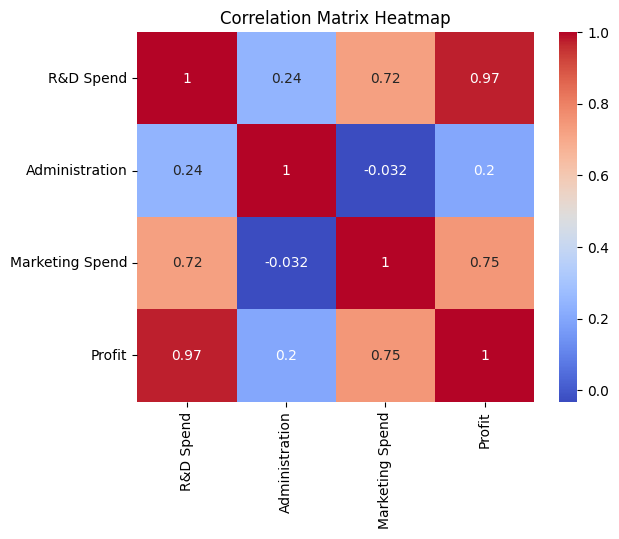

In [9]:
# 'numeric_only=True' ensures you don't hit errors with string columns
corr_matrix = df.corr(method='pearson', numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')

# Add a title and show the plot
plt.title('Correlation Matrix Heatmap')
plt.show()


[Text(0, 0, '17'), Text(0, 0, '17'), Text(0, 0, '16')]

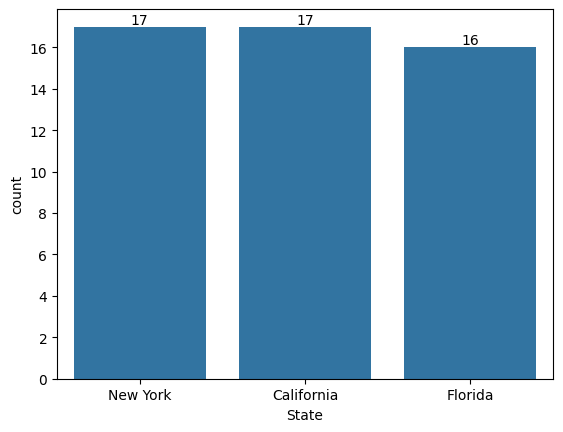

In [10]:
# Create the plot
ax = sns.countplot(data=df, x='State')

# Add the labels
ax.bar_label(ax.containers[0])

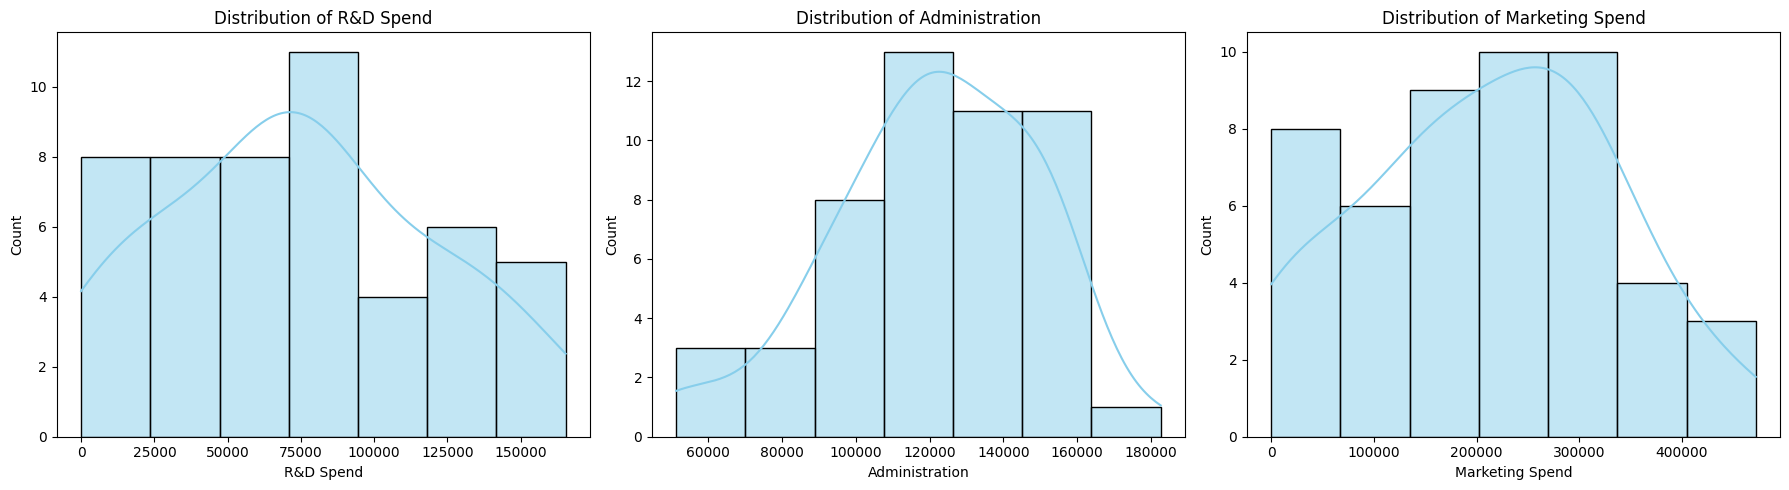

In [11]:
# Inspecting Skewness of each data
cols = ["R&D Spend", "Administration", "Marketing Spend"]

# Set up a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

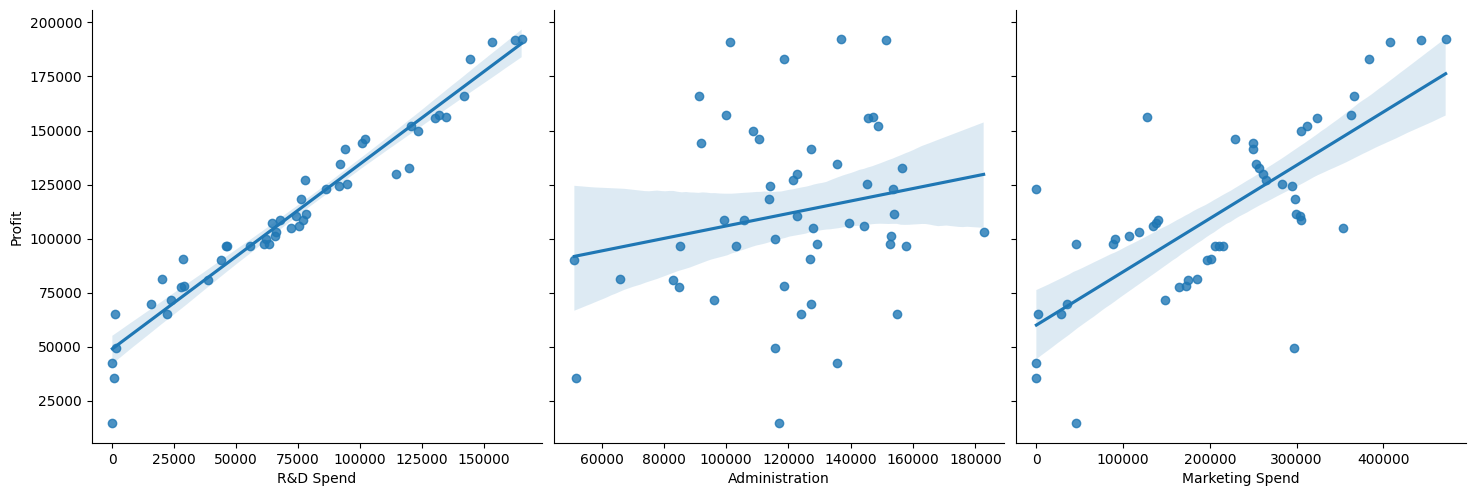

In [12]:
# This creates a matrix of plots

sns.pairplot(df, x_vars=["R&D Spend", "Administration", "Marketing Spend"], 
             y_vars=["Profit"], 
             kind="reg", 
             height=5)

plt.show()

In [13]:
# Replacing 0's with the mean values
cols_to_fix = ["Administration",'Profit']
df[cols_to_fix] = df[cols_to_fix].replace(0, np.nan) # Replacing 0 with nan else mean gets lower values
df[cols_to_fix] = df[cols_to_fix].fillna(df[cols_to_fix].mean()) # Fill the NaNs with the mean 

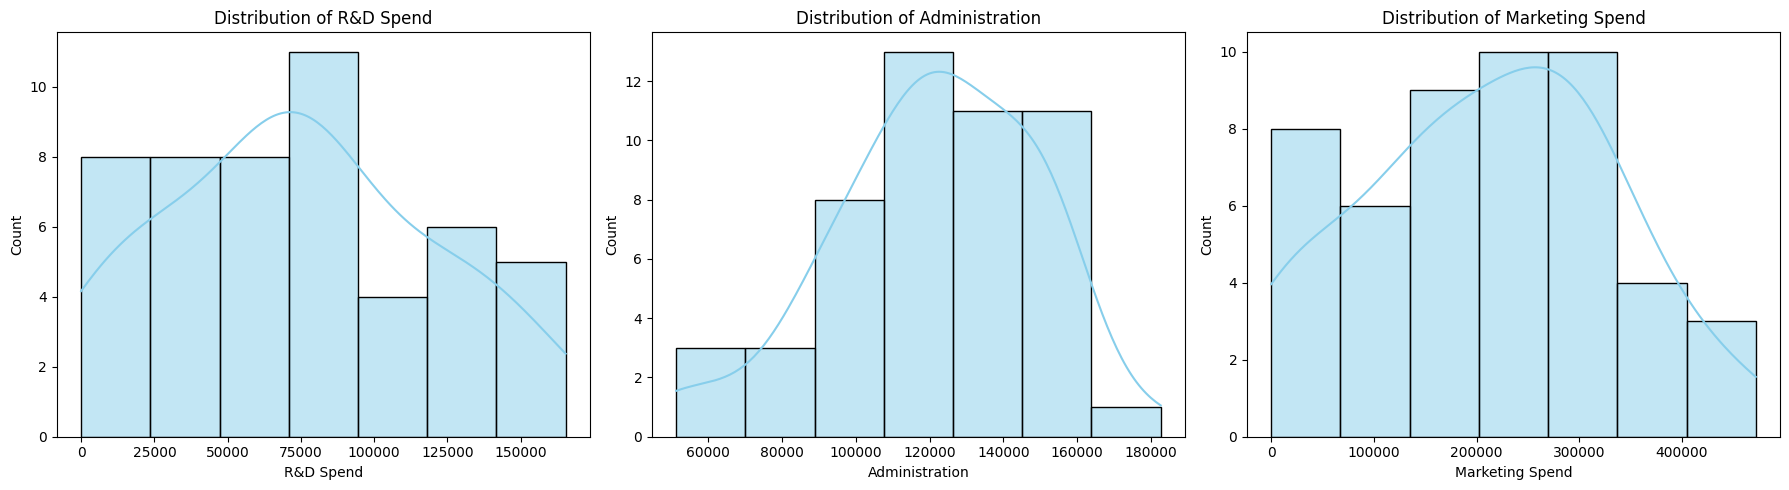

In [14]:
 # After changing 0 to the mean of their col
cols = ["R&D Spend", "Administration", "Marketing Spend"]

# Set up a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {col}')

plt.tight_layout()
plt.show()

In [15]:
df = pd.get_dummies(df, columns=['State'], drop_first=True,dtype=int)
df.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0


# **Standardization**

In [16]:
# 1. Define your columns (excluding Profit)
features_to_scale = ["R&D Spend", "Administration", "Marketing Spend"]

# 2. Initialize the Scaler
scaler = StandardScaler()

# 3. Apply Scaling to specific columns
# We use .fit_transform() because we want to learn the mean/std 
# and apply it in one step.
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

# View the result
print("Data after Standardization (Features only):")
print(df.head())

Data after Standardization (Features only):
   R&D Spend  Administration  Marketing Spend     Profit  State_Florida  \
0   2.016411        0.560753         2.153943  192261.83              0   
1   1.955860        1.082807         1.923600  191792.06              0   
2   1.754364       -0.728257         1.626528  191050.39              1   
3   1.554784       -0.096365         1.422210  182901.99              0   
4   1.504937       -1.079919         1.281528  166187.94              1   

   State_New York  
0               1  
1               0  
2               0  
3               1  
4               0  


In [17]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
count,5.000000e+01,5.000000e+01,5.000000e+01,50.000000,50.000000,50.000000
mean,-7.549517e-17,-2.564615e-16,-1.554312e-16,112012.639200,0.320000,0.340000
std,1.010153e+00,1.010153e+00,1.010153e+00,40306.180338,0.471212,0.478518
min,-1.622362e+00,-2.525994e+00,-1.743127e+00,14681.400000,0.000000,0.000000
25%,-7.434983e-01,-6.350458e-01,-6.750713e-01,90138.902500,0.000000,0.000000
50%,-1.475621e-02,4.885871e-02,1.396931e-02,107978.190000,0.000000,0.000000
75%,6.135700e-01,8.471792e-01,7.305723e-01,139765.977500,1.000000,1.000000
max,2.016411e+00,2.210141e+00,2.153943e+00,192261.830000,1.000000,1.000000


# ML

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

In [19]:
X = df[["R&D Spend", "Administration", "Marketing Spend", "State_Florida", "State_New York"]]
y = df["Profit"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
# Define your models in a dictionary for easy iteration
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=1.0),
    "ElasticNet": ElasticNet(alpha=1.0, l1_ratio=0.5)
}

In [22]:
# Initialize a list to store results
model_comparison = []

# Loop through the dictionary
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Calculate both
    mse = mean_squared_error(y_test, y_pred) # Stays in squared units
    rmse = root_mean_squared_error(y_test, y_pred) # Back to original units
    r2 = r2_score(y_test, y_pred)
    
    model_comparison.append({
        'Model': name,
        'MSE': round(mse, 2),
        'RMSE': round(rmse, 2),
        'R2 Score': round(r2, 4)
    })
# Convert to DataFrame
results_df = pd.DataFrame(model_comparison).sort_values(by='R2 Score', ascending=False)
print(results_df)

               Model           MSE      RMSE  R2 Score
2              Lasso  8.198768e+07   9054.70    0.8988
0  Linear Regression  8.201036e+07   9055.96    0.8987
1              Ridge  8.409338e+07   9170.24    0.8962
3         ElasticNet  1.254123e+08  11198.76    0.8451
